In [13]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim, dropout=0.2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=layer_dim,
            batch_first=True,
            dropout=dropout if layer_dim > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.layer_dim, x.size(0), self.hidden_dim).to(x.device)

        out, (hn, cn) = self.lstm(x, (h0, c0))
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out

In [14]:

def plot_loss(loss_list, test_loss_list):
    fig, ax1 = plt.subplots(figsize=(12, 10))

    # Loss
    ax1.plot(loss_list, label='Treino', linewidth=2)
    ax1.plot(test_loss_list, label='Teste', linewidth=2)
    ax1.set_xlabel("Época")
    ax1.set_ylabel("MSE Loss")
    ax1.set_title("Evolução da Loss durante o Treino")
    ax1.legend()
    ax1.grid(True)
    ax1.set_yscale('log')

    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.show()


def simulate_rnn_trajectory_xy(model, init_seq, scaler_xy, steps, noise_std=0.01):
    model.eval()
    current_seq = init_seq.clone().unsqueeze(0).to(device)
    trajectory = []

    with torch.no_grad():
        for step in range(steps):
            next_step = model(current_seq)

            """
            # Adicionar ruído controlado
            if noise_std > 0 and step > 0:  # Não adicionar no primeiro passo
                noise = torch.randn_like(next_step) * noise_std
                next_step = next_step + noise
            """

            trajectory.append(next_step.squeeze().cpu().numpy())

            next_step_exp = next_step.unsqueeze(1)
            current_seq = torch.cat([current_seq[:, 1:, :], next_step_exp], dim=1)

    trajectory = np.array(trajectory)
    trajectory = scaler_xy.inverse_transform(trajectory)
    x_pred, y_pred = trajectory[:, 0], trajectory[:, 1]
    return x_pred, y_pred


def find_corresponding_real_data(example_idx, datasets, idx_test, window, steps):
    dataset_idx = idx_test[example_idx].item()
    real_data = datasets[dataset_idx]

    start_pos = window
    end_pos = min(start_pos + steps, len(real_data["x_obs"]))
    actual_steps = end_pos - start_pos

    x_real = real_data["x_obs"][start_pos:end_pos]
    y_real = real_data["y_obs"][start_pos:end_pos]

    return x_real, y_real, actual_steps


def plot_trajectory(datasets, featuresTest, model, idx_test, scaler_xy, window, test_examples):
    for example_idx in test_examples:
        if example_idx >= len(featuresTest):
            continue

        print(f"\nExemplo: {example_idx} ---")

        init_seq = featuresTest[example_idx]
        desired_steps = 50

        x_pred, y_pred = simulate_rnn_trajectory_xy(model, init_seq, scaler_xy, steps=desired_steps, noise_std=0.005)

        x_real, y_real, actual_steps = find_corresponding_real_data(example_idx, datasets, idx_test, window, desired_steps)

        print(f"Predição: {len(x_pred)} pontos, Real: {len(x_real)} pontos")

        min_len = min(len(x_pred), len(x_real))
        x_pred = x_pred[:min_len]
        y_pred = y_pred[:min_len]
        x_real = x_real[:min_len]
        y_real = y_real[:min_len]

        position_error = np.sqrt((x_real - x_pred)**2 + (y_real - y_pred)**2)

        print(f"Exemplo {example_idx}:")
        print(f"Pontos comparados: {min_len}")
        print(f"Erro médio: {np.mean(position_error):.4f} m")
        print(f"Erro máximo: {np.max(position_error):.4f} m")

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

        ax1.plot(x_real, y_real, 'bo-', label="Real", markersize=4, alpha=0.7, linewidth=2)
        ax1.plot(x_pred, y_pred, 'rx-', label="Previsto (LSTM)", markersize=4, alpha=0.7, linewidth=2)
        ax1.set_xlabel("x [m]")
        ax1.set_ylabel("y [m]")
        ax1.set_title(f"Trajetória - Exemplo {example_idx}")
        ax1.legend()
        ax1.axis("equal")
        ax1.grid(True)


        ax2.plot(position_error, 'r-', linewidth=2)
        ax2.axhline(y=np.mean(position_error), color='b', linestyle='--',
                  label=f'Erro médio = {np.mean(position_error):.4f} m')
        ax2.set_xlabel('Passo de tempo')
        ax2.set_ylabel('Erro posicional (m)')
        ax2.set_title(f'Evolução do Erro')
        ax2.legend()
        ax2.grid(True)

        plt.tight_layout()
        plt.savefig(f'trajectory_comparison_{example_idx}.png')
        plt.show()


def plots(datasets, featuresTest, model, idx_test, scaler_xy, window, test_examples, loss_list, test_loss_list):
    plot_loss(loss_list, test_loss_list)
    plot_trajectory(datasets, featuresTest, model, idx_test, scaler_xy, window, test_examples)
    print("\n" + "="*50)
    print("ESTATÍSTICAS FINAIS")
    print("="*50)
    print(f"Épocas treinadas: {len(loss_list)}")
    print(f"Final loss de treino: {loss_list[-1]:.6f}")

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# carregando datasets
datasets = np.load("../input/simple/pendulum_datasets_with_noise.npy", allow_pickle=True)
print("Loaded:", len(datasets), "examples")

# janela de tempo pra previsão
window = 10

features_list = []
targets_list = []
dataset_idx_list = []

all_xy = np.concatenate([np.stack([d["x_obs"], d["y_obs"]], axis=-1) for d in datasets], axis=0)
scaler_xy = StandardScaler().fit(all_xy)

#cria sequencias com base na janela de tempo
for idx, data in enumerate(datasets):

    if len(data["x_obs"]) < window + 1:
        continue

    xy = np.stack([data["x_obs"], data["y_obs"]], axis=-1).astype(np.float32)
    xy_scaled = scaler_xy.transform(xy)

    Ns = len(xy_scaled)

    for i in range(Ns - window - 1):
        seq_in = xy_scaled[i:i+window]
        next_step = xy_scaled[i+window]

        features_list.append(seq_in)
        targets_list.append(next_step)
        dataset_idx_list.append(idx)

features_numpy = np.array(features_list, dtype=np.float32)
targets_numpy = np.array(targets_list, dtype=np.float32)
dataset_idx_numpy = np.array(dataset_idx_list)


print("features_numpy shape:", features_numpy.shape)
print("targets_numpy shape:", targets_numpy.shape)

featuresTensor = torch.tensor(features_numpy, dtype=torch.float32)
targetsTensor  = torch.tensor(targets_numpy, dtype=torch.float32)
dataset_idx_tensor = torch.tensor(dataset_idx_numpy)


# split 80/20
split = int(0.8 * len(featuresTensor))
featuresTrain, featuresTest = featuresTensor[:split], featuresTensor[split:]
targetsTrain, targetsTest = targetsTensor[:split], targetsTensor[split:]
idx_train, idx_test = dataset_idx_tensor[:split], dataset_idx_tensor[split:]

test_examples = [0, 5, 10]

Using device: cuda
Loaded: 500 examples
features_numpy shape: (7000, 10, 2)
targets_numpy shape: (7000, 2)


In [16]:
batch_size = 256
num_epochs = 200

train_dataset = TensorDataset(featuresTrain, targetsTrain)
test_dataset  = TensorDataset(featuresTest, targetsTest)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train batches:", len(train_loader))
print("Test batches :", len(test_loader))

input_dim = 2
hidden_dim = 128
layer_dim = 2
output_dim = 2

model = LSTMModel(input_dim, hidden_dim, layer_dim, output_dim).to(device)

error = nn.MSELoss()
learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)


Train batches: 22
Test batches : 6


In [17]:
loss_list = []
test_loss_list = []
learning_rates = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = error(outputs, targets)
        loss.backward()
        #torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)

    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for x_test, y_test in test_loader:
            x_test, y_test = x_test.to(device), y_test.to(device)
            y_pred = model(x_test)
            test_loss += error(y_pred, y_test).item()

    avg_test_loss = test_loss / len(test_loader)

    loss_list.append(avg_train_loss)
    test_loss_list.append(avg_test_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        #print(f"Epoch {epoch+1}/{num_epochs} | Train: {avg_train_loss:.6f} | Test: {avg_test_loss:.6f} | LR: {current_lr:.6f}")
        print(f"Epoch {epoch+1}/{num_epochs} | Train: {avg_train_loss:.6f} | Test: {avg_test_loss:.6f}")


Epoch 1/200 | Train: 0.745003 | Test: 0.537327
Epoch 10/200 | Train: 0.052728 | Test: 0.045464
Epoch 20/200 | Train: 0.037259 | Test: 0.031602
Epoch 30/200 | Train: 0.031225 | Test: 0.026638
Epoch 40/200 | Train: 0.029348 | Test: 0.025094
Epoch 50/200 | Train: 0.027406 | Test: 0.023515
Epoch 60/200 | Train: 0.026109 | Test: 0.023840
Epoch 70/200 | Train: 0.025142 | Test: 0.022632
Epoch 80/200 | Train: 0.025746 | Test: 0.023355
Epoch 90/200 | Train: 0.024465 | Test: 0.022763
Epoch 100/200 | Train: 0.024545 | Test: 0.022439
Epoch 110/200 | Train: 0.024382 | Test: 0.023170
Epoch 120/200 | Train: 0.024224 | Test: 0.022636
Epoch 130/200 | Train: 0.023412 | Test: 0.021634
Epoch 140/200 | Train: 0.023427 | Test: 0.021715
Epoch 150/200 | Train: 0.023664 | Test: 0.021285
Epoch 160/200 | Train: 0.023140 | Test: 0.021411
Epoch 170/200 | Train: 0.022617 | Test: 0.022060
Epoch 180/200 | Train: 0.022211 | Test: 0.021522
Epoch 190/200 | Train: 0.022812 | Test: 0.020906
Epoch 200/200 | Train: 0.021836

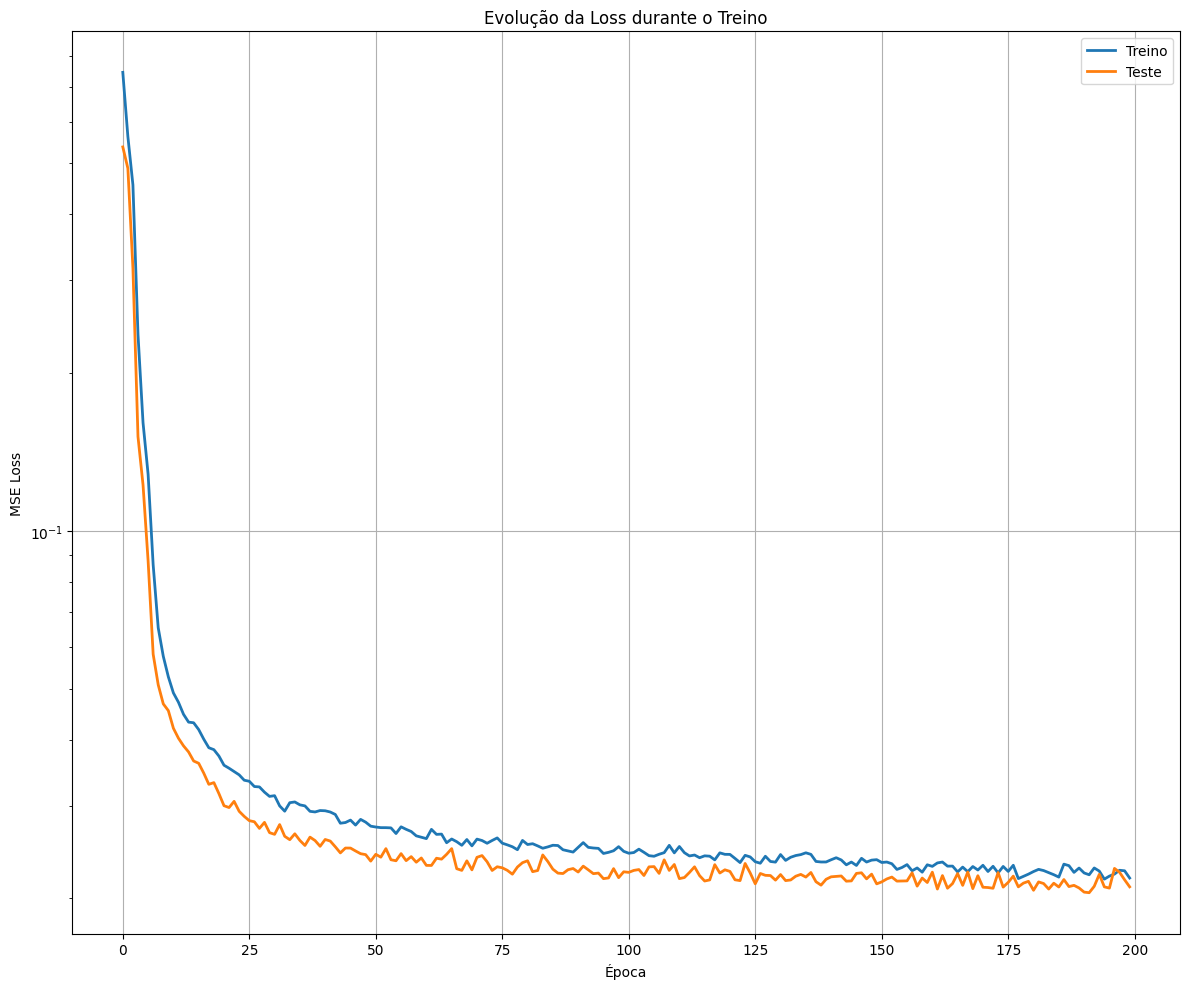


Exemplo: 0 ---
Predição: 50 pontos, Real: 15 pontos
Exemplo 0:
Pontos comparados: 15
Erro médio: 0.0522 m
Erro máximo: 0.1178 m


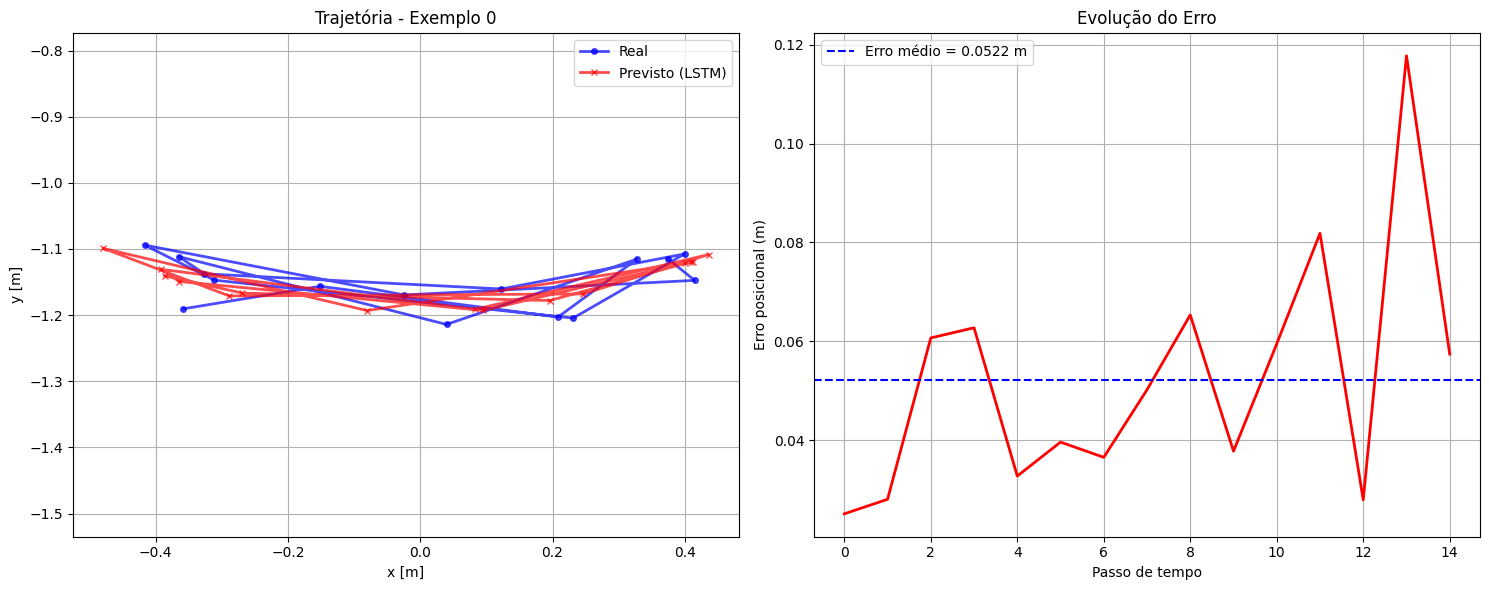


Exemplo: 5 ---
Predição: 50 pontos, Real: 15 pontos
Exemplo 5:
Pontos comparados: 15
Erro médio: 0.1330 m
Erro máximo: 0.2581 m


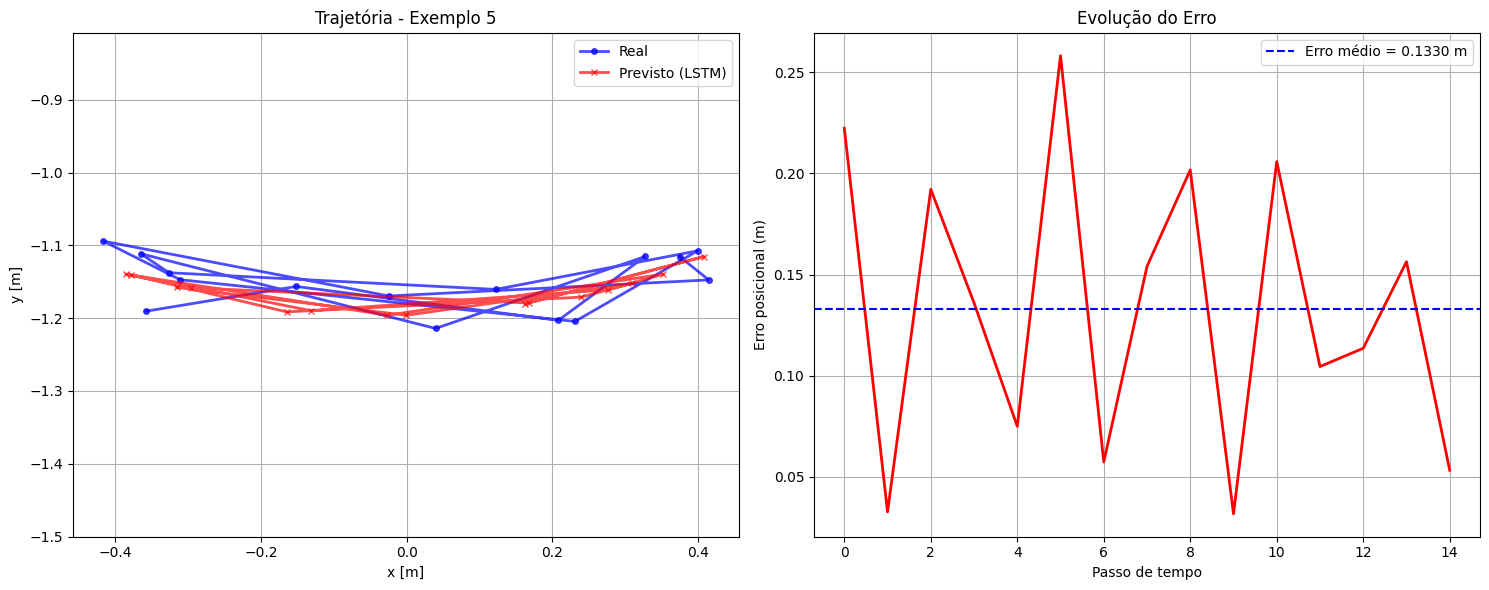


Exemplo: 10 ---
Predição: 50 pontos, Real: 15 pontos
Exemplo 10:
Pontos comparados: 15
Erro médio: 0.1661 m
Erro máximo: 0.3458 m


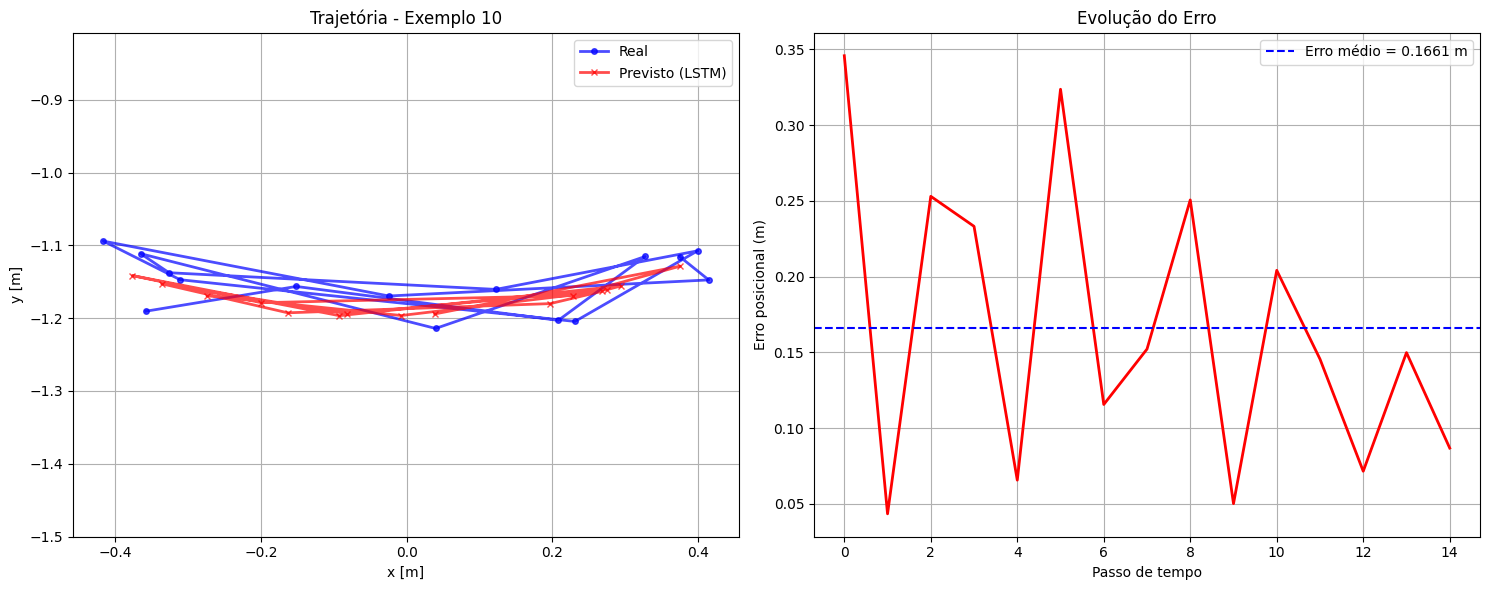


ESTATÍSTICAS FINAIS
Épocas treinadas: 200
Final loss de treino: 0.021836


In [18]:
plots(datasets, featuresTest, model, idx_test, scaler_xy, window, test_examples, loss_list, test_loss_list)

In [19]:
def physical_loss(inputs, delta_t = 0.1, L = 1.0):
        x_t_minus_1 = inputs[:, -2, 0]
        y_t_minus_1 = inputs[:, -2, 1]
        x_t = inputs[:, -1, 0]
        y_t = inputs[:, -1, 1]

        acc_x_pred = (x_pred - 2 * x_t + x_t_minus_1) / (delta_t ** 2)
        acc_y_pred = (y_pred - 2 * y_t + y_t_minus_1) / (delta_t ** 2)

        mean_xy = torch.tensor(scaler_xy.mean_, dtype=torch.float32).to(device)
        std_xy = torch.tensor(scaler_xy.scale_, dtype=torch.float32).to(device)

        x_t_unscaled = x_t * std_xy[0] + mean_xy[0]
        y_t_unscaled = y_t * std_xy[1] + mean_xy[1]


        theta_t = torch.atan2(x_t_unscaled, -y_t_unscaled)
        acc_x_phys = -(9.81 / L) * torch.sin(theta_t)
        acc_y_phys = -(9.81 / L) * torch.cos(theta_t)

        acc_x_phys_scaled = acc_x_phys / (std_xy[0] / delta_t**2)
        acc_y_phys_scaled = acc_y_phys / (std_xy[1] / delta_t**2)


        acc_x_pred_unscaled = acc_x_pred * std_xy[0]
        acc_y_pred_unscaled = acc_y_pred * std_xy[1]

        return torch.mean((acc_x_pred_unscaled - acc_x_phys) ** 2 + (acc_y_pred_unscaled - acc_y_phys) ** 2)

In [20]:

batch_size = 256
num_epochs = 200

train_dataset = TensorDataset(featuresTrain, targetsTrain)
test_dataset  = TensorDataset(featuresTest, targetsTest)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Train batches:", len(train_loader))
print("Test batches :", len(test_loader))

input_dim = 2
hidden_dim = 128
layer_dim = 2
output_dim = 2

model = LSTMModel(input_dim, hidden_dim, layer_dim, output_dim).to(device)

error = nn.MSELoss()
learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

Train batches: 22
Test batches : 6


In [21]:
loss_list = []
test_loss_list = []
learning_rates = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    epoch_phys_loss = 0.0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)

        x_pred, y_pred = outputs[:, 0], outputs[:, 1]
        x_real, y_real = targets[:, 0], targets[:, 1]

        loss_data = error(x_pred, x_real) + error(y_pred, y_real)

        loss_phys = physical_loss(inputs)

        loss = loss_data + 1e-21 * loss_phys
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
        epoch_phys_loss += loss_phys.item() if isinstance(loss_phys, torch.Tensor) else loss_phys

    avg_train_loss = epoch_loss / len(train_loader)
    avg_phys_loss = epoch_phys_loss / len(train_loader)


    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for x_test, y_test in test_loader:
            x_test, y_test = x_test.to(device), y_test.to(device)
            y_pred = model(x_test)
            test_loss += error(y_pred, y_test).item()

    avg_test_loss = test_loss / len(test_loader)


    loss_list.append(avg_train_loss)
    test_loss_list.append(avg_test_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{num_epochs} | "
                f"Train: {avg_train_loss:.6f} | "
                f"Test: {avg_test_loss:.6f} | "
                f"Phys: {avg_phys_loss:.6f}")




Epoch 1/200 | Train: 1.507545 | Test: 0.545132 | Phys: 8005.074774
Epoch 10/200 | Train: 0.097374 | Test: 0.042411 | Phys: 4732.898238
Epoch 20/200 | Train: 0.069204 | Test: 0.030613 | Phys: 4661.575550
Epoch 30/200 | Train: 0.061858 | Test: 0.026383 | Phys: 4649.544478
Epoch 40/200 | Train: 0.056077 | Test: 0.024683 | Phys: 4643.735551
Epoch 50/200 | Train: 0.054845 | Test: 0.025762 | Phys: 4625.819181
Epoch 60/200 | Train: 0.052718 | Test: 0.023247 | Phys: 4616.827259
Epoch 70/200 | Train: 0.052619 | Test: 0.022654 | Phys: 4634.092729
Epoch 80/200 | Train: 0.049669 | Test: 0.022879 | Phys: 4634.815075
Epoch 90/200 | Train: 0.047583 | Test: 0.022630 | Phys: 4624.724765
Epoch 100/200 | Train: 0.049144 | Test: 0.023117 | Phys: 4621.151567
Epoch 110/200 | Train: 0.048528 | Test: 0.022050 | Phys: 4633.479026
Epoch 120/200 | Train: 0.047638 | Test: 0.021439 | Phys: 4629.425315
Epoch 130/200 | Train: 0.047161 | Test: 0.021607 | Phys: 4627.154275
Epoch 140/200 | Train: 0.046616 | Test: 0.021

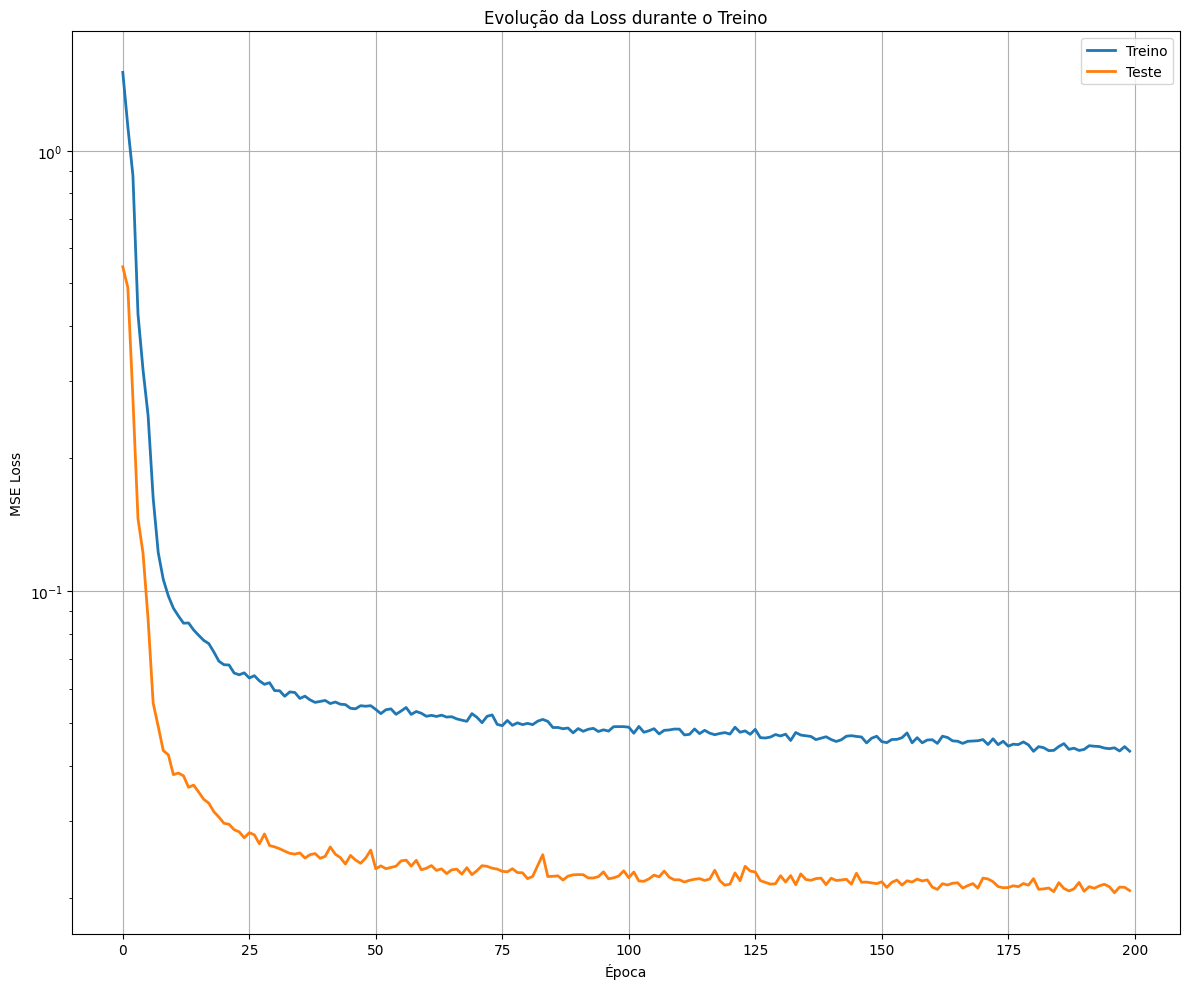


Exemplo: 0 ---
Predição: 50 pontos, Real: 15 pontos
Exemplo 0:
Pontos comparados: 15
Erro médio: 0.0610 m
Erro máximo: 0.1357 m


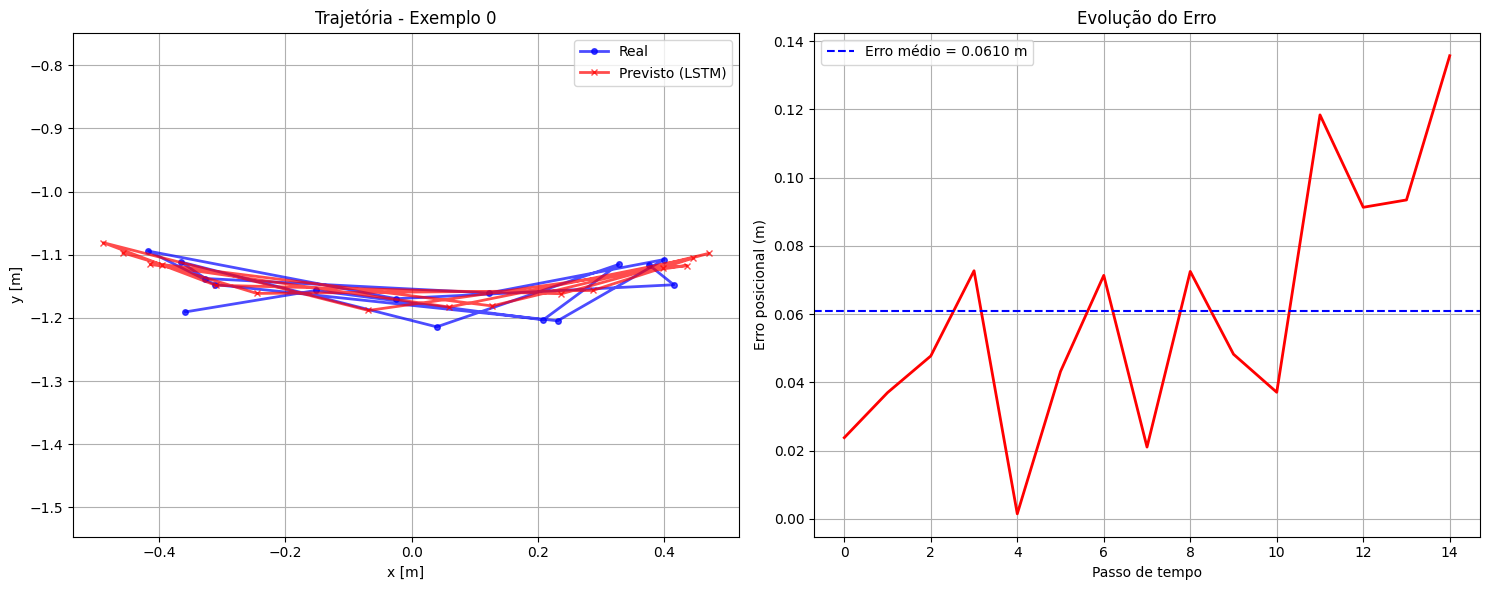


Exemplo: 5 ---
Predição: 50 pontos, Real: 15 pontos
Exemplo 5:
Pontos comparados: 15
Erro médio: 0.1445 m
Erro máximo: 0.2650 m


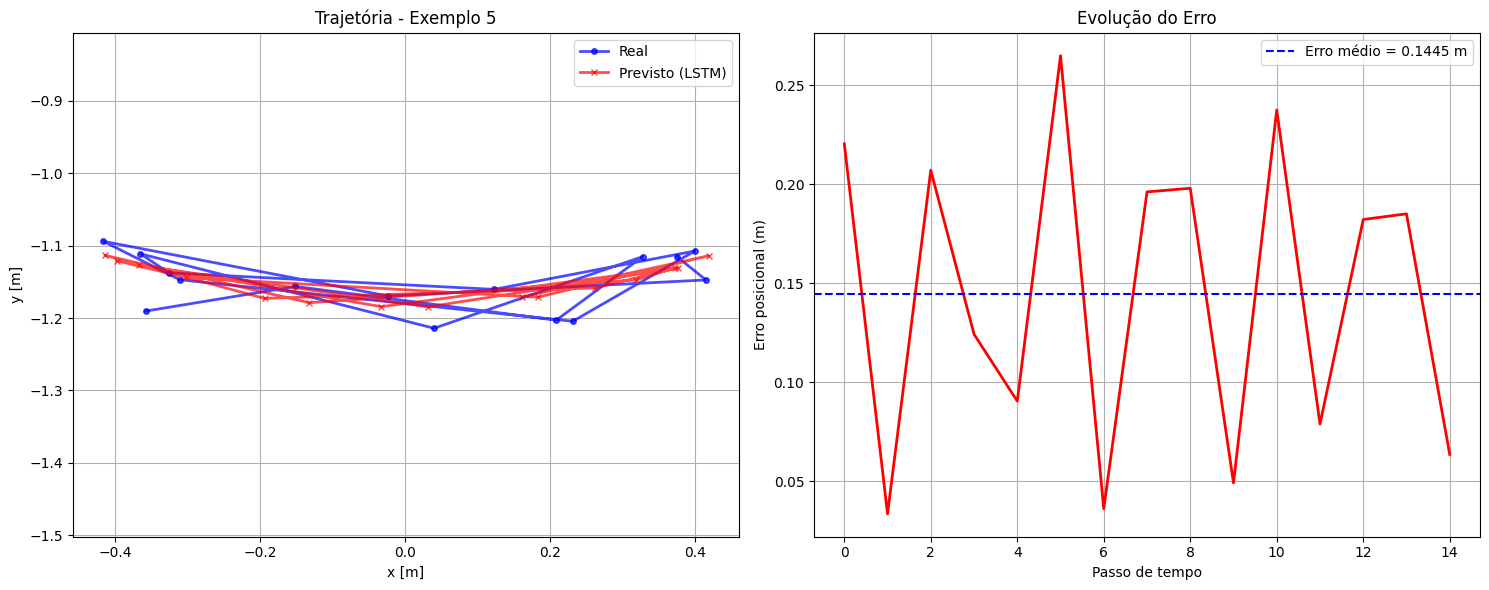


Exemplo: 10 ---
Predição: 50 pontos, Real: 15 pontos
Exemplo 10:
Pontos comparados: 15
Erro médio: 0.1742 m
Erro máximo: 0.3416 m


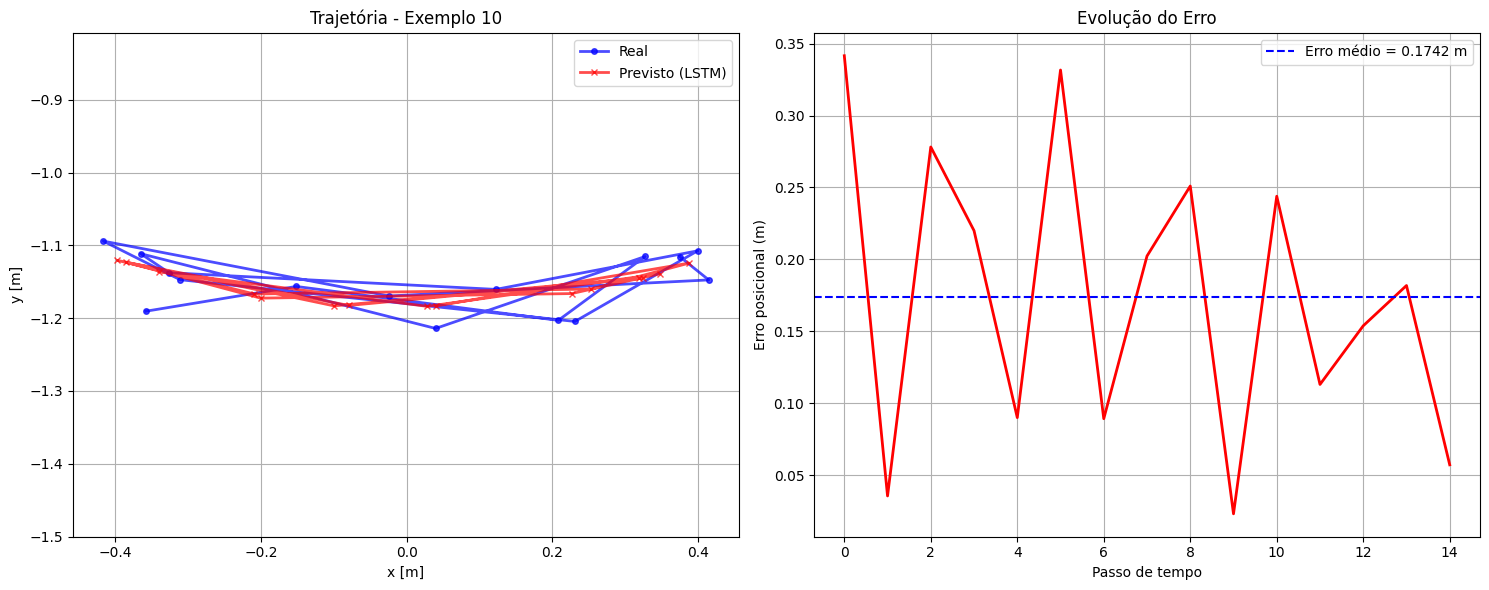


ESTATÍSTICAS FINAIS
Épocas treinadas: 200
Final loss de treino: 0.043230


In [22]:
plots(datasets, featuresTest, model, idx_test, scaler_xy, window, test_examples, loss_list, test_loss_list)